In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm


In [2]:
ECPath = "/share/sabl0586/all_stations_EC-Earth_PRCP2SZDST_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(ECPath, chunks={})
stations = ds["station"].values
TestStation = ['SMR-II']
radii = np.arange(20,51)



In [3]:
def ECearthExtract_Dask(ECPath, station, chunks="auto"):
    """
    Lazily load EC-Earth data using Dask and optionally compute PNSD.

    Parameters
    ----------
    ECPath : str
        Path to EC-Earth NetCDF file.
    station : str
        Station name or coordinate.
    chunks : str or dict, optional
        Dask chunking specification. Default 'auto'.
    """

    import xarray as xr

    #Open lazily with Dask
    Data = xr.open_dataset(ECPath, chunks=chunks)
    Data = Data.sel(station=station)

    ds = xr.Dataset()
    PNSD_ds = xr.Dataset()
    cdnc = xr.Dataset()
    ds_IFS = xr.Dataset()


    #Define variables for the ERF
    radius_variables = ['RDRY_NUS', 'RDRY_AIS', 'RDRY_ACS', 'RWET_AII', 'RDRY_COS', 'RWET_ACI', 'RWET_COI']
    Numb_variables = ['N_NUS', 'N_AIS', 'N_ACS', 'N_AII', 'N_COS', 'N_ACI', 'N_COI']
    ModesSigma = [1.59, 1.59, 1.59, 2.0, 1.59, 1.59, 2.0]
    
    for radius, number in zip(radius_variables, Numb_variables):
        if radius in Data and number in Data:
            ds[radius] = Data[radius]*1e9
            ds[radius].attrs["units"] = "nm"
            #print(f' {radius} added to Dataset')
            ds[number] = Data[number]/1e6
            ds[number].attrs["units"] = "#cm-3"
            #print(f' {number} added to Dataset')
        else:
            print(f'{radius, number} not found in EC Path Data')
            
    # ADD PRESSURE TO DATASET        
    ds['pressure'] = Data['pressure']

    #Converting the IFS levels to match the EC-Earth Levs
    for ifs in [['var20', 'var22', 'var54']]:
        ds_IFS[ifs] = Data[ifs]
    ds_IFS = ds_IFS[['var20', 'var22', 'var54']].isel(lev=0).drop_vars('lev')
    ds_IFS['lev_ifs'] = ds_IFS['var54'].mean('time')

    
    return ds, ds_IFS

In [4]:
CCN_CDNC_all_ls = []

for station in stations:
    print(station)
    EC_ds, ds_ifs = ECearthExtract_Dask(ECPath, station, chunks="auto")
            
    #Pressure to Datasets, interpolate the IFS levels 
    EC_ds['lev'] = EC_ds['pressure'].mean('time')
    EC_ds['lev'] = EC_ds.lev.compute()
    ds_ifs['lev_ifs'] = ds_ifs.lev_ifs.compute()
    ds_IFS = ds_ifs.rename({'lev_ifs': 'lev'})
    ds_IFS = ds_IFS.assign_coords(lev=ds_IFS['lev'])
    target_lev = EC_ds['lev']
    ds_ifs_interp = ds_IFS.interp(lev=target_lev)
    EC_ds['lev'] = EC_ds['lev'] / 100
    EC_ds["lev"].attrs["units"] = "hPa" 
    #print('Converting lev to hPa')
    
    # Compute CDNC and drop lev_ifs
    cdnc = (ds_ifs_interp["var20"] / ds_ifs_interp["var22"]).where(ds_ifs_interp["var22"] > 0).compute()
    cdnc['lev'] = cdnc['lev'] / 100
    cdnc["lev"].attrs["units"] = "hPa" 
    #print('Converting lev to hPa')
    CCN_ds = Function.ECEarthERF(EC_ds, radii)
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, cdnc)
        # Build dataset
    CCN_CDNC_ds = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,
            'CDNC': CDNC_aligned
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': target_lev,
            'time': CCN_aligned.time
        }
    )
    CCN_CDNC_all_ls.append(CCN_CDNC_ds.assign_coords(station=station))
CCN_CDNC_all_ds = xr.concat(CCN_CDNC_all_ls, dim='station')


ZEP


/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


SMR-II


/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


ATTO


...

/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Izana


/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Maldives


/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/pech2273/.conda/envs/thesis_env/lib/python3.12/site-packages/dask/array/core.py:4888: PerformanceWarning: Increasing number of chunks by factor of 11
  result = blockwise(
/home/pech2273/.conda/envs/thesis_env/lib/python

In [6]:
def Suceptibility_by_Level(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

    OLS_slope, OLS_intercept = xr.apply_ufunc(
        Function.OLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    ODR_slope, ODR_intercept = xr.apply_ufunc(
        Function.TLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    Deming_slope, Deming_intercept = xr.apply_ufunc(
        Function.deming_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    PCA_slope, PCA_intercept = xr.apply_ufunc(
        Function.PCA_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )

    ds_out = xr.Dataset(
        data_vars={
            'OLS slope': (('radius', 'lev'), OLS_slope.data),
            'OLS intercept': (('radius', 'lev'), OLS_intercept.data),
            'ODR slope': (('radius', 'lev'), ODR_slope.data),
            'ODR intercept': (('radius', 'lev'), ODR_intercept.data),
            'Deming slope': (('radius', 'lev'), Deming_slope.data),
            'Deming intercept': (('radius', 'lev'), Deming_intercept.data),
            'PCA slope': (('radius', 'lev'), PCA_slope.data),
            'PCA intercept': (('radius', 'lev'), PCA_intercept.data),

        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,

        }
    )
    ds_out2 = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out, ds_out2


In [9]:
def compute_allLev(CCN_ds, CDNC_da):
    """
    Compute OLS and TLS slope/intercept per radius,
    flattening across all levels and times.
    Returns a Dataset with variables: slope_OLS, intercept_OLS, slope_TLS, intercept_TLS
    """
    # Align CCN and CDNC over lev and time
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)
    
    #Rechunk the data
    CCN_aligned = CCN_aligned.chunk({'lev': -1, 'time': -1})
    CDNC_aligned = CDNC_aligned.chunk({'lev': -1, 'time': -1})

    # Broadcast CDNC to match CCN dimensions
    CDNC_broadcast = CDNC_aligned.broadcast_like(CCN_aligned)

    # --- OLS ---
    slope_OLS, intercept_OLS = xr.apply_ufunc(
        Function.OLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )

    # --- TLS ---
    slope_TLS, intercept_TLS = xr.apply_ufunc(
        Function.TLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    
    # --- Deming ---
    slope_Deming, intercept_Deming = xr.apply_ufunc(
        Function.deming_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    # --- PCA ---
    slope_PCA, intercept_PCA = xr.apply_ufunc(
        Function.PCA_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )


    # Package into dataset
    ds_out = xr.Dataset(
        data_vars={
            'All_Level_OLS_slope': (('radius',), slope_OLS.data),
            'All_Level_OLS_intercept': (('radius',), intercept_OLS.data),
            'All_Level_TLS_slope': (('radius',), slope_TLS.data),
            'All_Level_TLS_intercept': (('radius',), intercept_TLS.data),
            'All_Level_Deming_slope': (('radius',), slope_Deming.data),
            'All_Level_Deming_intercept': (('radius',), intercept_Deming.data),
            'All_Level_PCA_slope': (('radius',), slope_PCA.data),
            'All_Level_PCA_intercept': (('radius',), intercept_PCA.data),

        },
        coords={
            'radius': CCN_aligned.radius,

        }
    )

    return ds_out

In [10]:
all_stations = []
all_stationsCCN = []
for station in stations:
    print(station)
    CCN_ds = CCN_CDNC_all_ds['CCN'].sel(station = station)
    cdnc = CCN_CDNC_all_ds['CDNC'].sel(station = station)
    # Caculate the Susceptibilility
    Level_susc_ds, Levels_CCN_ds = Suceptibility_by_Level(CCN_ds, cdnc)
    Susceptibility_AllLevs = compute_allLev(CCN_ds, cdnc)
    
    Susceptibility_ds = xr.merge([Level_susc_ds, Susceptibility_AllLevs])
    
    all_stations.append(Susceptibility_ds.assign_coords(station=station))
    all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))

# Concatenate across stations
Susceptibility_all = xr.concat(all_stations, dim='station')
CCN_all = xr.concat(all_stationsCCN, dim='station')

ZEP
SMR-II
ATTO
MHD
SGP
CHC
BIR-II
PAL
Vavihill
JFJ
FKL
SMEAR-I
Villum
Izana
Maldives


In [14]:
Susceptibility_all['All_Level_OLS_slope'].sel(station = 'ATTO').values

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan])

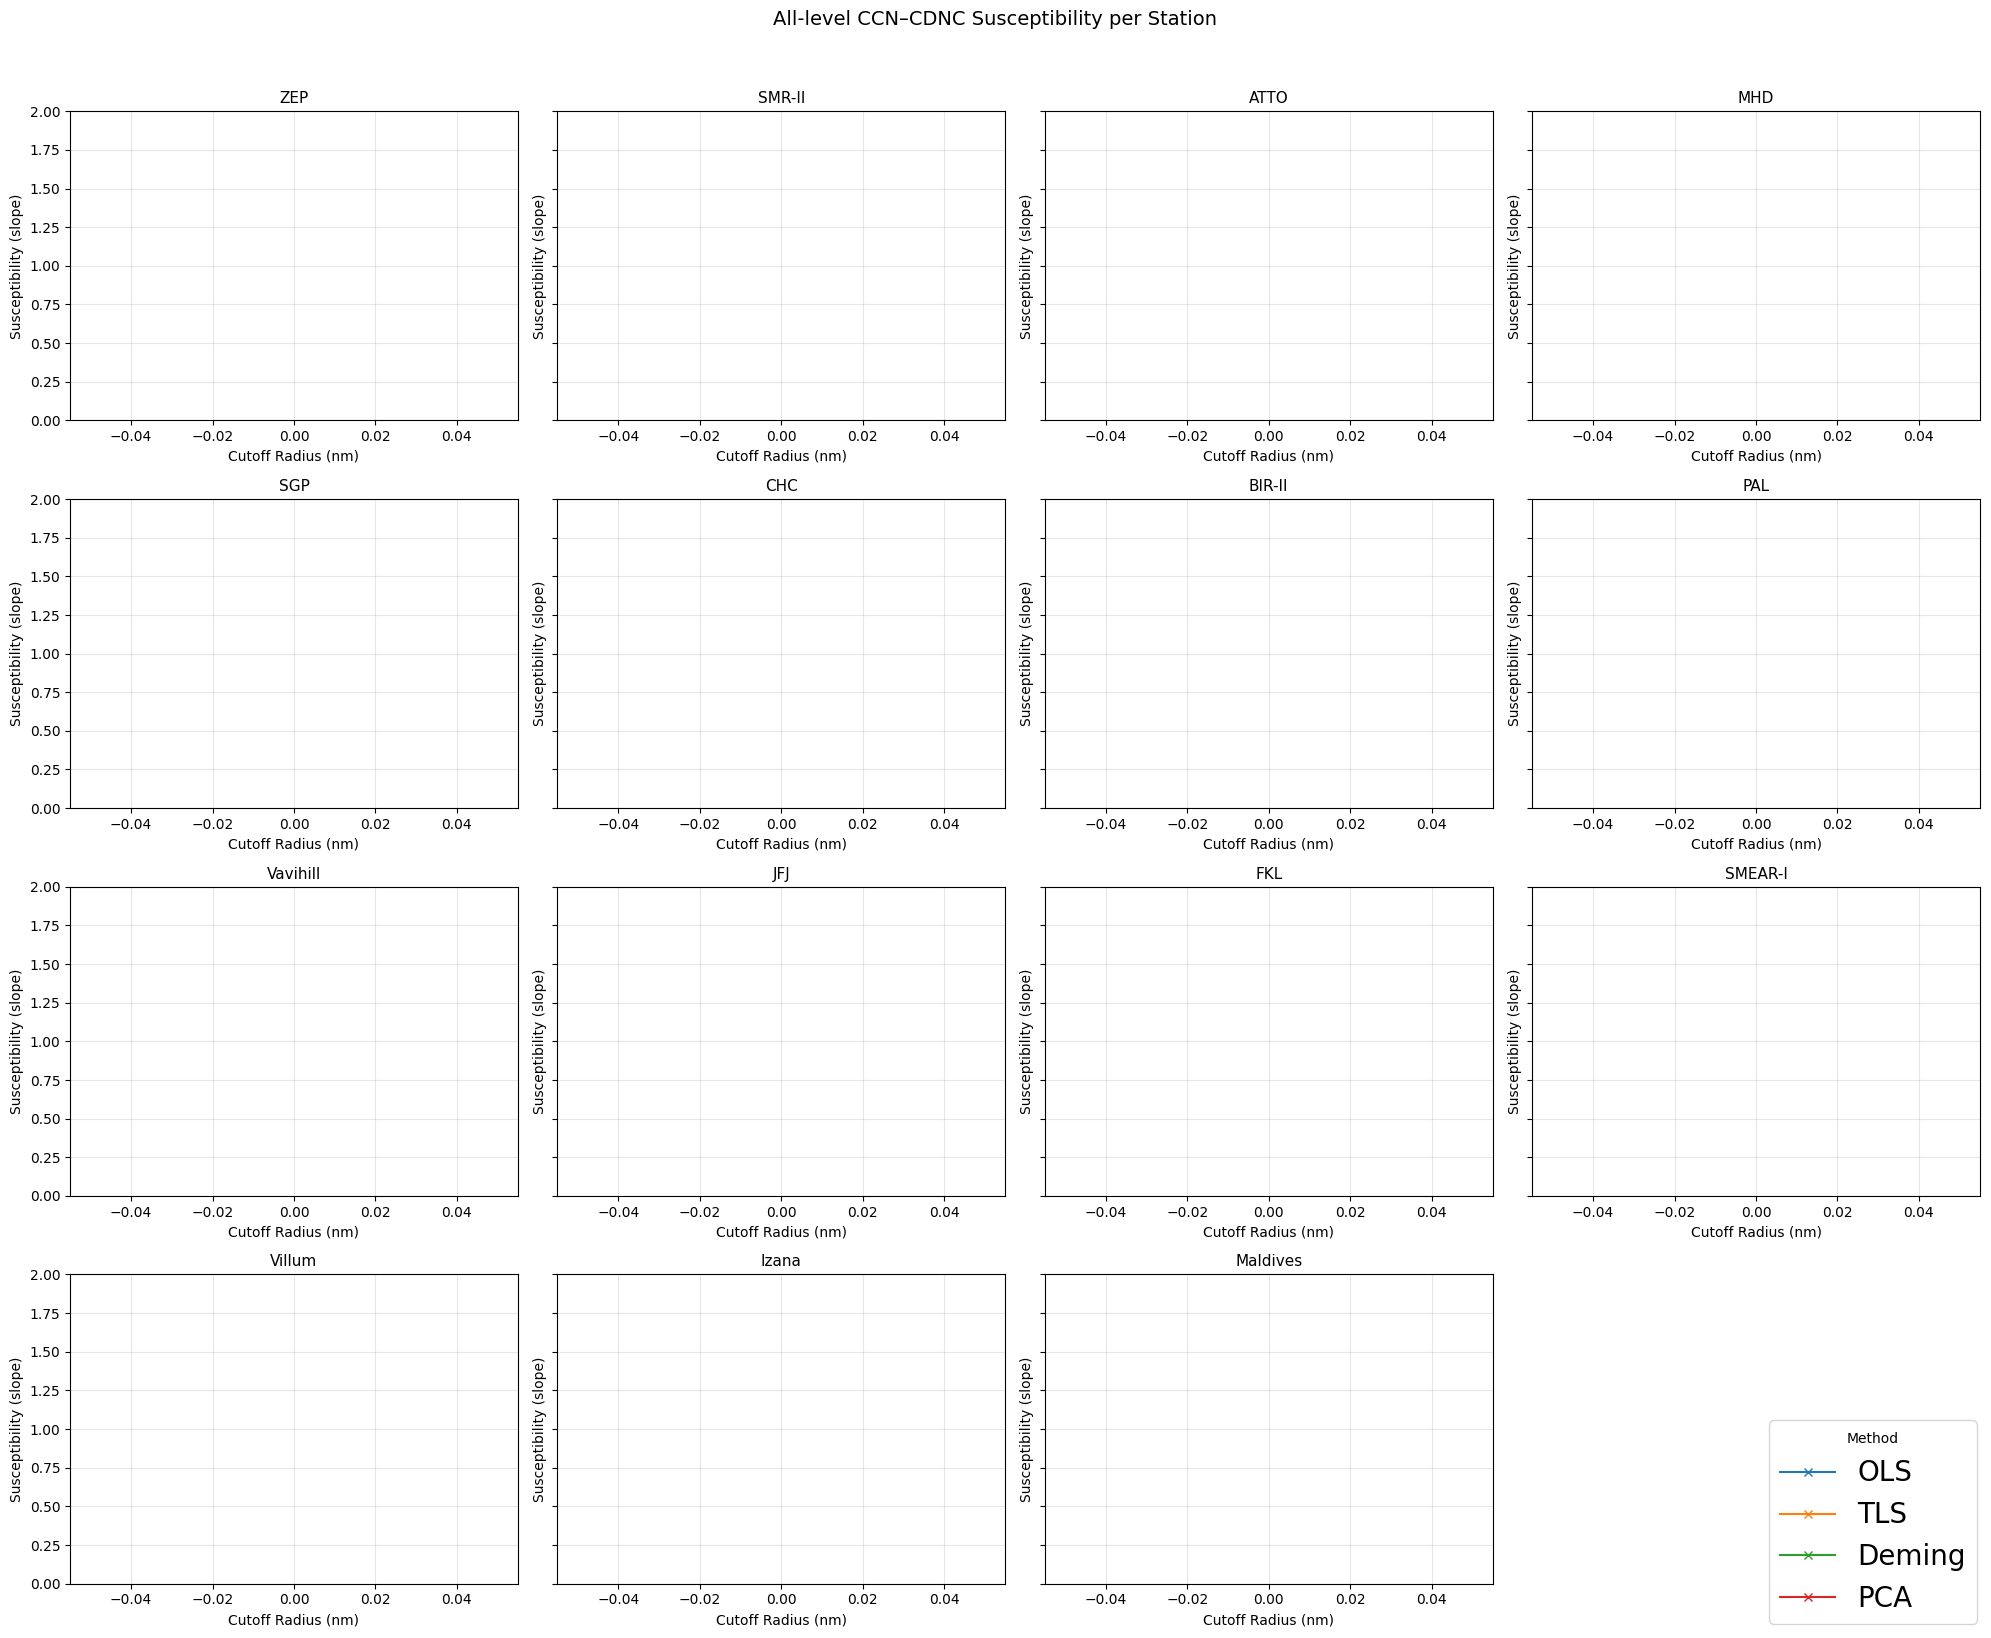

In [12]:
stations = Susceptibility_all.station.values
methods = ["OLS", "TLS", "Deming", "PCA"]

# Define number of columns and rows dynamically
ncols = 4
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4 * nrows),
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    for method in methods:
        var_name = f"All_Level_{method}_slope"
        if var_name in Susceptibility_all:
            Susceptibility_all[var_name].sel(station=station).plot(
                ax=ax, marker='x', label=method
            )
    ax.set_title(f"{station}", fontsize=11)
    ax.set_xlabel("Cutoff Radius (nm)")
    ax.set_ylabel("Susceptibility (slope)")
    ax.set_ylim(0, 2)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(stations), len(axes)):
    axes[j].set_visible(False)

# Add a global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc="lower right", fontsize=20)

fig.suptitle("All-level CCN–CDNC Susceptibility per Station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
